<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Multiple Testing &amp; Sharpe Inference
    </h1>
  </div>
</div>

When you screen *many* strategies and keep the best, the winner's Sharpe ratio is
inflated by selection. The **Deflated Sharpe Ratio (DSR)** corrects the single
maximum-Sharpe strategy for the number of trials. But often the real question is
about a whole **family**: which of these factors are genuine discoveries? That is a
multiple-testing problem, and `RiskLabAI.backtest` provides the Harvey-Liu (2015)
haircuts: **Holm** controls the family-wise error rate (the chance of *any* false
positive) and **Benjamini-Hochberg-Yekutieli (BHY)** controls the false discovery
rate (the *expected fraction* of false positives).

Separately, even a single Sharpe ratio is hard to test when returns are serially
correlated. The PSR corrects for skew and kurtosis but assumes serial independence,
so it over-rejects under autocorrelation. **LPLZ** (Lopez de Prado-Lipton-Zoonekynd
2025) applies a Newey-West HAC to the Sharpe influence function, restoring correct
inference.

In [1]:
import warnings
warnings.filterwarnings("ignore")

# --- Local source bootstrap -------------------------------------------------
# The admitted Stage-1 methods demonstrated here are merged in the RiskLabAI.py
# source tree but not yet in a tagged PyPI release, so we put the local source
# ahead of any installed copy. Once these ship in a release this block is a
# no-op and a plain `pip install RiskLabAI` is enough.
import sys
from pathlib import Path
_cands = [p / "RiskLabAI.py" for p in [Path.cwd(), *Path.cwd().parents]]
_cands.append(Path(r"C:/risklab/risklabai/RiskLabAI.py"))
for _src in _cands:
    if (_src / "RiskLabAI" / "__init__.py").exists():
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({  # theme-adaptive figures: transparent bg + neutral-gray foreground
    "figure.facecolor": "none", "axes.facecolor": "none",
    "savefig.facecolor": "none", "savefig.transparent": True,
    "text.color": "#888888", "axes.labelcolor": "#888888", "axes.titlecolor": "#888888",
    "axes.edgecolor": "#888888", "xtick.color": "#888888", "ytick.color": "#888888",
    "grid.color": "#888888", "grid.alpha": 0.3, "legend.framealpha": 0.0,
})


In [2]:
from RiskLabAI.backtest import (
    haircut_sharpe_ratios,        # Holm (FWER) and BHY (FDR) Sharpe haircuts
    expected_max_sharpe_ratio,    # DSR building block: E[max Sharpe] under multiplicity
    probabilistic_sharpe_ratio,   # PSR: skew/kurtosis-aware, assumes serial independence
    lplz_sharpe_inference,        # LPLZ HAC Sharpe inference (serial-correlation robust)
)
from scipy import stats

## 1. A family of screened strategies

We screen 20 strategies over 120 months. Three carry a genuine small edge; the
other 17 are pure noise. We compute each strategy's per-period Sharpe ratio, the raw
material for both the DSR and the family haircuts.

In [3]:
rng = np.random.default_rng(3)
n_obs, n_real = 120, 3
strategies = []
for i in range(20):
    mu = 0.012 if i < n_real else 0.0          # only the first three have edge
    r = rng.standard_normal(n_obs) * 0.04 + mu
    strategies.append(r)
sharpes = np.array([r.mean() / r.std(ddof=1) for r in strategies])
order = np.argsort(sharpes)[::-1]
print("top 6 in-sample Sharpe ratios (per period):")
for rank, i in enumerate(order[:6], 1):
    tag = "REAL edge" if i < n_real else "noise"
    print(f"   #{rank}: strategy {i:2d}  SR={sharpes[i]:+.3f}  ({tag})")

top 6 in-sample Sharpe ratios (per period):
   #1: strategy  2  SR=+0.389  (REAL edge)
   #2: strategy  1  SR=+0.355  (REAL edge)
   #3: strategy  0  SR=+0.246  (REAL edge)
   #4: strategy  4  SR=+0.155  (noise)
   #5: strategy 17  SR=+0.139  (noise)
   #6: strategy 10  SR=+0.131  (noise)


## 2. Deflating the single best vs judging the family

The DSR asks whether the *one* best strategy survives its trial count. The expected
maximum Sharpe under pure noise grows with the number of trials, so the bar the
winner must clear rises with how many strategies you tried. That handles the single
winner, but it says nothing about which *other* members of the family are real.

In [4]:
sr_std = sharpes.std()
for n_trials in (1, 5, 20):
    bar = expected_max_sharpe_ratio(n_trials, mean_sharpe_ratio=0.0, std_sharpe_ratio=sr_std)
    print(f"trials={n_trials:2d}:  expected max Sharpe under noise = {bar:.3f}  "
          f"(the winner must beat this)")
print(f"\nobserved best Sharpe = {sharpes.max():.3f}")

trials= 1:  expected max Sharpe under noise = 0.000  (the winner must beat this)
trials= 5:  expected max Sharpe under noise = 0.159  (the winner must beat this)
trials=20:  expected max Sharpe under noise = 0.253  (the winner must beat this)

observed best Sharpe = 0.389


## 3. Holm (FWER) and BHY (FDR) haircuts on the family

`haircut_sharpe_ratios` converts each Sharpe to a p-value, adjusts the whole family,
and reports which survive and the **haircut** (shrunken) Sharpe after the multiplicity
penalty. Holm is the stricter family-wise control; BHY controls the false discovery
rate and so is more powerful (it lets more through) at a controlled error fraction.

In [5]:
def summarise(method):
    res = haircut_sharpe_ratios(sharpes, number_of_returns=n_obs, method=method)
    df = pd.DataFrame({
        "raw_SR": sharpes,
        "adj_p_value": res["adjusted_p_values"],
        "significant": res["significant"],
        "haircut_SR": res["haircut_sharpe_ratios"],
    })
    return df.sort_values("raw_SR", ascending=False).head(6).round(4)

print("=== Holm (family-wise error rate) ===")
print(summarise("holm"))
print("\n=== BHY (false discovery rate) ===")
print(summarise("bhy"))

=== Holm (family-wise error rate) ===
    raw_SR  adj_p_value  significant  haircut_SR
2   0.3895       0.0002         True      0.3233
1   0.3552       0.0009         True      0.2836
0   0.2457       0.0640        False      0.1390
4   0.1552       0.7568        False     -0.0636
17  0.1387       1.0000        False        -inf
10  0.1313       1.0000        False        -inf

=== BHY (false discovery rate) ===
    raw_SR  adj_p_value  significant  haircut_SR
2   0.3895       0.0007         True      0.2911
1   0.3552       0.0018         True      0.2659
0   0.2457       0.0852        False      0.1251
4   0.1552       0.8009        False     -0.0771
17  0.1387       0.9019        False     -0.1180
10  0.1313       0.9019        False     -0.1180


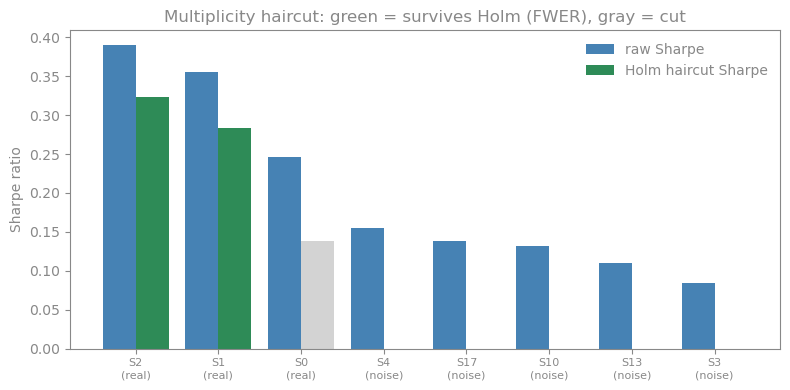

In [6]:
holm = haircut_sharpe_ratios(sharpes, number_of_returns=n_obs, method="holm")
order6 = np.argsort(sharpes)[::-1][:8]
labels = [f"S{i}\n({'real' if i < n_real else 'noise'})" for i in order6]
raw = sharpes[order6]
cut = np.clip(holm["haircut_sharpe_ratios"][order6], 0, None)  # clip -inf for display
colors = ["seagreen" if holm["significant"][i] else "lightgray" for i in order6]

fig, ax = plt.subplots(figsize=(8, 4))
xpos = np.arange(len(order6))
ax.bar(xpos - 0.2, raw, width=0.4, label="raw Sharpe", color="steelblue")
ax.bar(xpos + 0.2, cut, width=0.4, label="Holm haircut Sharpe", color=colors)
ax.set_xticks(xpos); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Sharpe ratio")
ax.set_title("Multiplicity haircut: green = survives Holm (FWER), gray = cut")
ax.legend()
plt.tight_layout(); plt.show()

## 4. Sharpe inference under serial correlation: PSR vs LPLZ

Now a single-strategy question: is the Sharpe ratio significantly positive? We run a
**size** check. Generate returns with **zero true Sharpe** but positive
autocorrelation (AR(1)), then count how often each method rejects the null at 5%.
The PSR, assuming serial independence, rejects far too often; LPLZ's HAC correction
restores near-nominal size.

In [7]:
def ar1_returns(n, phi, seed, mu=0.0, sigma=0.01):
    r = np.random.default_rng(seed)
    e = r.standard_normal(n) * sigma
    x = np.zeros(n)
    for t in range(1, n):
        x[t] = phi * x[t - 1] + e[t]
    return x + mu

n_sims, psr_rej, lplz_rej = 300, 0, 0
for s in range(n_sims):
    r = ar1_returns(500, phi=0.4, seed=s, mu=0.0)        # true Sharpe = 0
    sr = r.mean() / r.std(ddof=1)
    skew = float(stats.skew(r)); kurt = float(stats.kurtosis(r, fisher=False))
    psr = probabilistic_sharpe_ratio(sr, 0.0, len(r),
                                     skewness_of_returns=skew, kurtosis_of_returns=kurt)
    psr_rej += (psr > 0.95)
    res = lplz_sharpe_inference(r)
    lplz_rej += (res["p_value"] < 0.05 and res["sharpe_ratio"] > 0)
print(f"false-positive rate under AR(1), true Sharpe = 0 (nominal 0.05):")
print(f"   PSR  (assumes independence): {psr_rej / n_sims:.3f}   (inflated ~3x)")
print(f"   LPLZ (HAC corrected)       : {lplz_rej / n_sims:.3f}   (near nominal)")

false-positive rate under AR(1), true Sharpe = 0 (nominal 0.05):
   PSR  (assumes independence): 0.153   (inflated ~3x)
   LPLZ (HAC corrected)       : 0.027   (near nominal)


## Takeaways

- To judge a **family** of screened strategies, prefer **Holm** when you must control
  the chance of *any* false positive (FWER), and **BHY** when you want to bound the
  *expected fraction* of false discoveries (FDR) and can accept lower power.
- The **DSR** remains the tool for whether one specific best strategy survives its
  trial count.
- For **single-Sharpe inference under serial correlation and/or non-normality**,
  prefer **LPLZ**: it restores near-nominal size and CI coverage where the PSR
  over-rejects (here PSR size approximately triples the nominal 5%). LPLZ converges
  to the PSR on near-normal i.i.d. returns; the honest cost is wider intervals.

All functions come from `RiskLabAI.backtest`.